# Machine Learning Modeling: Predict Falcon 9 First-Stage Landing Success

First-stage landings are a key driver of SpaceX reusability and cost reduction. If we can predict landing success from mission and vehicle characteristics, we can better understand what operational factors matter most, and build a baseline predictive model.

This notebook trains and evaluates a few classification models to predict whether a Falcon 9 first stage lands successfully (`Class = 1`) or not (`Class = 0`). It used the cleaned and feature-engineered datasets produced earlier in this project.

**Inputs:**

- `../data/processed/03_dataset_part_2.csv` engineered launch records (includes the target column `Class`)

- `../data/processed/05_dataset_part_3.csv` one-hot encoded feature matrix used for modeling

**Outputs:**

- `../data/processed/08_model_performance.csv` test accuracy + CV scores + best parameters

- `../data/processed/08_best_model.json` selected best model name + best parameters

## Notebook outline

1. Setup

2. Load prepared datasets

3. Prepare features and target

4. Train + tune models

5. Compare models on the held-out test set

6. Save results artifacts

---

## 1. Setup

Import libraries and define a small helper function for plotting confusion matrices.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn import preprocessing
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier

from pathlib import Path
import json

# Paths
DATA_PROCESSED = Path('..') / 'data' / 'processed'
DATA_RAW = Path('..') / 'data' / 'raw'

DATASET_PART_2 = DATA_PROCESSED / '03_dataset_part_2.csv'
DATASET_PART_3 = DATA_PROCESSED / '05_dataset_part_3.csv'

# Artifacts
MODEL_PERF_OUT = DATA_PROCESSED / '08_model_performance.csv'
BEST_MODEL_OUT = DATA_PROCESSED / '08_best_model.json'

In [2]:
# Helper: confusion matrix plot
def plot_confusion_matrix(y, y_predict):
    'This function plots the confusion matrix'
    from sklearn.metrics import confusion_matrix

    cm = confusion_matrix(y, y_predict)
    ax = plt.subplot()
    sns.heatmap(cm, annot = True, ax = ax); #annot = True to annotate cells
    ax.set_xlabel('Predicted labels')
    ax.set_ylabel('True labels')
    ax.set_title('Confusion Matrix'); 
    ax.xaxis.set_ticklabels(['did not land', 'land']); ax.yaxis.set_ticklabels(['did not land', 'landed']) 
    plt.show() 

## 2. Load prepared datasets

We load:

- the label dataset (contains ´Class´)

- the one-hot encoded feature matrix (numeric features only)

Both files are expected to exist from earlier notebooks.

Load the data from `../data/processed`.

In [4]:
# Load engineered launch records
data = pd.read_csv(DATASET_PART_2)

data.head()

,FlightNumber,Date,BoosterVersion,PayloadMass,Orbit,LaunchSite,Outcome,Flights,GridFins,Reused,Legs,LandingPad,Block,ReusedCount,Serial,Longitude,Latitude,Class
0,1,2010-06-04,Falcon 9,6123.547647,LEO,CCSFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B0003,-80.577366,28.561857,0
1,2,2012-05-22,Falcon 9,525.000000,LEO,CCSFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B0005,-80.577366,28.561857,0
2,3,2013-03-01,Falcon 9,677.000000,ISS,CCSFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B0007,-80.577366,28.561857,0
3,4,2013-09-29,Falcon 9,500.000000,PO,VAFB SLC 4E,False Ocean,1,False,False,False,NaN,1.0,0,B1003,-120.610829,34.632093,0
4,5,2013-12-03,Falcon 9,3170.000000,GTO,CCSFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B1004,-80.577366,28.561857,0


In [5]:
print('dataset_part_2 shape:', data.shape)
print('Class distribution:', data['Class'].value_counts().to_dict())

dataset_part_2 shape: (90, 18)
Class distribution: {1: 60, 0: 30}


In [6]:
# Load one-hot encoded feature matrix
X = pd.read_csv(DATASET_PART_3)

X.head()

,FlightNumber,PayloadMass,Flights,GridFins,Reused,Legs,Block,ReusedCount,Orbit_ES-L1,Orbit_GEO,...,Serial_B1048,Serial_B1049,Serial_B1050,Serial_B1051,Serial_B1054,Serial_B1056,Serial_B1058,Serial_B1059,Serial_B1060,Serial_B1062
0,1.0,6123.547647,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,2.0,525.000000,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,3.0,677.000000,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,4.0,500.000000,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,5.0,3170.000000,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [7]:
print('dataset_part_3 shape:', X.shape)

dataset_part_3 shape: (90, 80)


## 3. Prepare target and features

We build:

- `Y`: target vector (landing success)

- `X`: standardized feature matrix

Create the target array `Y` from the `Class` column.

In [8]:
Y = data['Class'].to_numpy()

Standardize features (as in the original lab).

In [9]:
transform = preprocessing.StandardScaler()
X = transform.fit_transform(X)

Split the data into train/test sets (80/20).

Use `train_test_split` with `test_size = 0.2` and `random_state = 2` for reproducibility.

This creates: `X_train, X_test, Y_train, Y_test`.

In [11]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size = 0.2, random_state = 2)

# Check number of test samples
print("Number of test samples:", Y_test.shape)

Number of test samples: (18,)


## 4. Model training with hyperparameter search

We tune each model with a small grid search using 10-fold-cross-validation, then evaluate tuned performance on the held-out test set.

#### 4.1 Logistic Regression

Grid search over a small `C` range (L2 penalty).

In [12]:
parameters ={
    'C': [0.01, 0.1, 1],
    'penalty': ['l2'], 
    'solver': ['lbfgs']} # l1 lasso l2 ridge

lr = LogisticRegression()

logreg_cv = GridSearchCV(lr, parameters, cv = 10)
logreg_cv.fit(X_train, Y_train)

/opt/anaconda3/envs/datasc3135/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/opt/anaconda3/envs/datasc3135/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/opt/anaconda3/envs/datasc3135/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be remov

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",LogisticRegression()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'C': [0.01, 0.1, ...], 'penalty': ['l2'], 'solver': ['lbfgs']}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",10
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also displayed;- >3 : t

In [14]:
# Best hyperparameters and cross-validated training score (mean CV accuracy)
print('Tuned hyperparameters (best parameters): ', logreg_cv.best_params_)
print('Accuracy: ', logreg_cv.best_score_)

Tuned hyperparameters (best parameters):  {'C': 0.1, 'penalty': 'l2', 'solver': 'lbfgs'}
Accuracy:  0.8214285714285714


In [15]:
# Evaluate logistic regression on the held-out test split
logreg_accuracy = logreg_cv.score(X_test, Y_test)
print('Accuracy on test data: ', logreg_accuracy)

Accuracy on test data:  0.8333333333333334


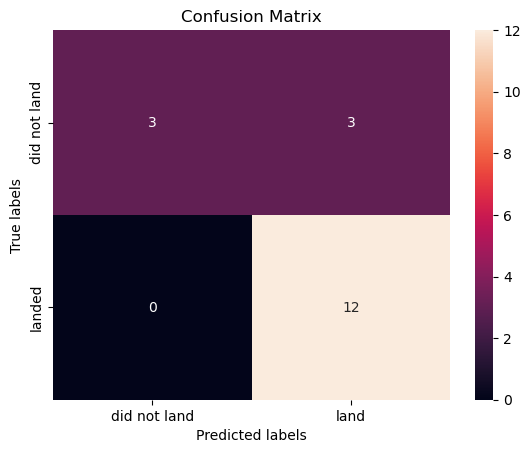

In [16]:
# Confusion matric for logistic regression
yhat = logreg_cv.predict(X_test)
plot_confusion_matrix(Y_test, yhat)

*Interpretation note:* the confusion matrix helps spot whether errors are mostly false positives or false negatives.

#### 4.2 Support Vector Machine (SVC)

In [17]:
# Tune kernel/C/gamma with 10-fold CV
parameters = {'kernel': ('linear', 'rbf', 'poly', 'rbf', 'sigmoid'),
              'C': np.logspace(-3, 3, 5),
              'gamma': np.logspace(-3, 3, 5)}
svm = SVC()

In [18]:
svm_cv = GridSearchCV(svm, parameters, cv = 10)
svm_cv.fit(X_train, Y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",SVC()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'C': array([1.0000...00000000e+03]), 'gamma': array([1.0000...00000000e+03]), 'kernel': ('linear', ...)}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",10
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score

In [19]:
print('Tuned hyperparameters (best parameters): ', svm_cv.best_params_)
print('Accuracy: ', svm_cv.best_score_)

Tuned hyperparameters (best parameters):  {'C': np.float64(1.0), 'gamma': np.float64(0.03162277660168379), 'kernel': 'sigmoid'}
Accuracy:  0.8482142857142858


In [20]:
# Evaluate SVC on the test split.
svm_accuracy = svm_cv.score(X_test, Y_test)
print('Accuracy on test data: ', svm_accuracy)

Accuracy on test data:  0.8333333333333334


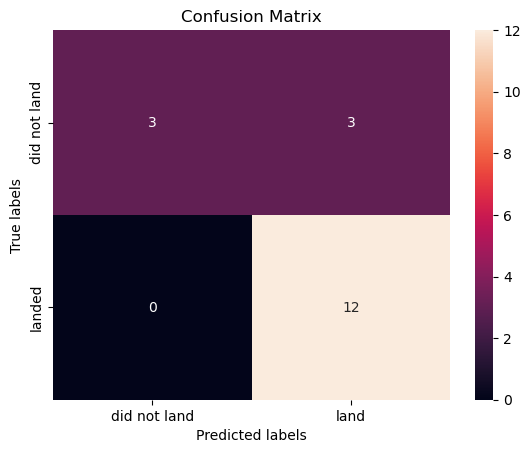

In [21]:
# Confusion matrix for SVC
yhat = svm_cv.predict(X_test)
plot_confusion_matrix(Y_test, yhat)

#### 4.3 Decision Tree

In [22]:
parameters = {'criterion': ['gini', 'entropy'],
     'splitter': ['best', 'random'],
     'max_depth': [2 * n for n in range(1, 10)],
     'max_features': ['auto', 'sqrt'],
     'min_samples_leaf': [1, 2, 4],
     'min_samples_split': [2, 5, 10]}

tree = DecisionTreeClassifier(random_state = 2)

In [23]:
tree_cv = GridSearchCV(tree, parameters, cv = 10)
tree_cv.fit(X_train, Y_train)

/opt/anaconda3/envs/datasc3135/lib/python3.13/site-packages/sklearn/model_selection/_validation.py:490: FitFailedWarning: 
3240 fits failed out of a total of 6480.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
3240 fits failed with the following error:
Traceback (most recent call last):
  File "/opt/anaconda3/envs/datasc3135/lib/python3.13/site-packages/sklearn/model_selection/_validation.py", line 833, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
    ~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/opt/anaconda3/envs/datasc3135/lib/python3.13/site-packages/sklearn/base.py", line 1329, in wrapper
    estimator._validate_params()
    ~~~~~~~~~~~~~~~~~~~~~~~~~~^^
  File "/opt/anaconda3/envs/datasc3135/lib/pyt

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",DecisionTreeC...andom_state=2)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'criterion': ['gini', 'entropy'], 'max_depth': [2, 4, ...], 'max_features': ['auto', 'sqrt'], 'min_samples_leaf': [1, 2, ...], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",10
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold a

In [24]:
print('Tuned hyperparameters (best parameters): ', tree_cv.best_params_)
print('Accuracy: ', tree_cv.best_score_)

Tuned hyperparameters (best parameters):  {'criterion': 'entropy', 'max_depth': 8, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 10, 'splitter': 'random'}
Accuracy:  0.8321428571428571


In [25]:
# Evaluate Decision Tree on the test split
tree_accuracy = tree_cv.score(X_test, Y_test)
print('Accuracy on test data: ', tree_accuracy)

Accuracy on test data:  0.6666666666666666


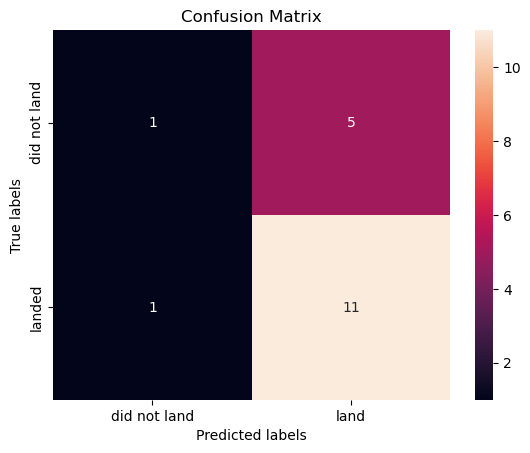

In [26]:
# Confusion matrix for Decision Tree
yhat = tree_cv.predict(X_test)
plot_confusion_matrix(Y_test, yhat)

#### 4.4 k-Nearest Neighbors (kNN)

In [ ]:
# Tune the number of neighbors and distance metric p
parameters = {'n_neighbors': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
              'algorithm': ['auto', 'ball_tree', 'kd_tree', 'brute'],
              'p': [1, 2]}

KNN = KNeighborsClassifier()

In [28]:
knn_cv = GridSearchCV(KNN, parameters, cv = 10)
knn_cv.fit(X_train, Y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",KNeighborsClassifier()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'algorithm': ['auto', 'ball_tree', ...], 'n_neighbors': [1, 2, ...], 'p': [1, 2]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",10
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is al

In [29]:
print('Tuned hyperparameters (best parameters): ', knn_cv.best_params_)
print('Accuracy: ', knn_cv.best_score_)

Tuned hyperparameters (best parameters):  {'algorithm': 'auto', 'n_neighbors': 3, 'p': 1}
Accuracy:  0.8339285714285714


In [30]:
# Evaluate KNN on the test split
knn_accuracy = knn_cv.score(X_test, Y_test)
print('Accuracy on test data: ', knn_accuracy)

Accuracy on test data:  0.7777777777777778


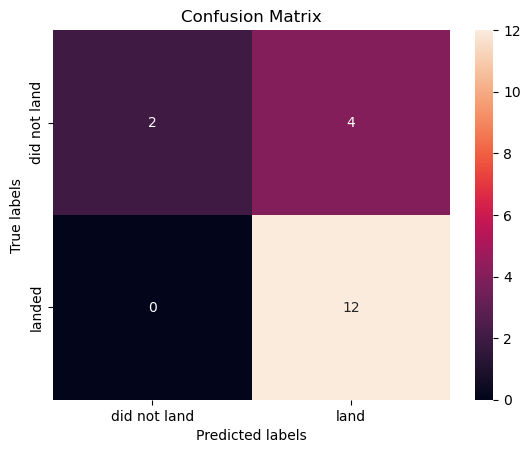

In [31]:
# Confusion matrix for KNN
yhat = knn_cv.predict(X_test)
plot_confusion_matrix(Y_test, yhat)

## 5. Compare tuned models

We compare test accuracies. If multiple models tie, we break ties using the cross-validated training score (`best_score_`) from the grid search.

In [34]:
# Summarize accuracies and select the best model.
model_accuracies = {
    'Logistic Regression': logreg_accuracy,
    'Support Vector Machine': svm_accuracy,
    'Decision Tree': tree_accuracy,
    'K Nearest Neighbors': knn_accuracy
}

print('Model Accuracies on Test Data:')

for model, accuracy in model_accuracies.items():
    print(f'{model}: {accuracy:.4f}')

best_accuracy = max(model_accuracies.values())
best_models = [model for model, accuracy in model_accuracies.items() if accuracy == best_accuracy]

print('Best Model(s):', ', '.join(best_models))
print(f'Best Accuracy: {best_accuracy:.4f}')

# Tie-breaker: pick highest CV best_score_ among tied models
cv_objects = {
    'Logistic Regression': logreg_cv,
    'Support Vector Machine': svm_cv,
    'Decision Tree': tree_cv,
    'K Nearest Neighbors': knn_cv
}

if len(best_models) > 1:
    tied_cv_scores = {m: cv_objects[m].best_score_ for m in best_models}
    best_model = max(tied_cv_scores, key = tied_cv_scores.get)

    print('\nTie-break (highest CV best_score_): ')
    for m, s in tied_cv_scores.items():
        print(f'{m} CV score: {s:.4f}')

    print('\nSelected Best Model: ', best_model)
    print(f'Selected CV Score: {tied_cv_scores[best_model]:.4f}')
else:
    best_model = best_models[0]
    print('\nSelected Best Model: ', best_model)


Model Accuracies on Test Data:
Logistic Regression: 0.8333
Support Vector Machine: 0.8333
Decision Tree: 0.6667
K Nearest Neighbors: 0.7778
Best Model(s): Logistic Regression, Support Vector Machine
Best Accuracy: 0.8333

Tie-break (highest CV best_score_): 
Logistic Regression CV score: 0.8214
Support Vector Machine CV score: 0.8482

Selected Best Model:  Support Vector Machine
Selected CV Score: 0.8482


## 6. Export results

We save a small summary table of model performance and the selected best model + parameters.

In [35]:
# Build a compact performance summary (test accuracy + CV score + best params)
model_perf = pd.DataFrame(
    [{
        'model': 'Logistic Regression',
        'test_accuracy': float(logreg_accuracy),
        'cv_best_score': float(logreg_cv.best_score_),
        'best_params': logreg_cv.best_params_
    },
         
    {
        'model': 'Support Vector Machine',
        'test_accuracy': float(svm_accuracy),
        'cv_best_score': float(svm_cv.best_score_),
        'best_params': svm_cv.best_params_
    },

    {
        'model': 'Decision Tree',
        'test_accuracy': float(tree_accuracy),
        'cv_best_score': float(tree_cv.best_score_),
        'best_params': tree_cv.best_params_
    },

    {
        'model': 'K Nearest Neighbors',
        'test_accuracy': float(knn_accuracy),
        'cv_best_score': float(knn_cv.best_score_),
        'best_params': knn_cv.best_params_
    }
])

# Show a compact comparison table
print(model_perf[['model', 'test_accuracy', 'cv_best_score']].to_string(index = False))

# Save CSV
model_perf.to_csv(MODEL_PERF_OUT, index = False)

# Save JSON (best model + params)
best_payload = {
    'selected_best_model': best_model,
    'model_performance_csv': MODEL_PERF_OUT.as_posix(),
    'best_params': cv_objects[best_model].best_params_ if 'cv_objects' in globals() else None
}

BEST_MODEL_OUT.write_text(json.dumps(best_payload, indent = 2, ensure_ascii = False), encoding = 'utf-8')

                 model  test_accuracy  cv_best_score
   Logistic Regression       0.833333       0.821429
Support Vector Machine       0.833333       0.848214
         Decision Tree       0.666667       0.832143
   K Nearest Neighbors       0.777778       0.833929


222